In [1]:
# import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

In [2]:
# read the veteran dataset
df = pd.read_csv('PreProcesseddataset_ifn580_262_v1.csv')

# show all columns information
print(df.convert_dtypes().info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  Int64
 1   passanger             12684 non-null  Int64
 2   weather               12684 non-null  Int64
 3   temperature           12684 non-null  Int64
 4   time                  12684 non-null  Int64
 5   coupon                12684 non-null  Int64
 6   expiration            12684 non-null  Int64
 7   gender                12684 non-null  Int64
 8   age                   12684 non-null  Int64
 9   maritalStatus         12684 non-null  Int64
 10  has_children          12684 non-null  Int64
 11  education             12684 non-null  Int64
 12  occupation            12684 non-null  Int64
 13  income                12684 non-null  Int64
 14  Bar                   12684 non-null  Int64
 15  CoffeeHouse           12684 non-null  Int64
 16  Carr

In [3]:
# our goal is is_accepted
# Obtain a list of labels (targets) for each of the samples. We refer to this as 'y'.
y = df["is_accepted"].values
# Remove the label (target) from the samples, as this is not a feature that we want to use to predict against.
# axis=1 is used to drop the column, instead of the row.
X = df.drop(['is_accepted'], axis=1)
# Pull out the column names before grabbing the feature array, we will need it later
feature_names = X.columns
# We use X.values to get arrays for the features, instead of a DataFrame with column names etc.
X = X.values

In [4]:
from sklearn.model_selection import train_test_split
# Create a 30% train/test split from our samples.
# We set the random_state to the constant 10 to ensure it is the same from run-to-run.
# We set the stratisfy parameter to the labels, that way we get an even selection of 0 and 1 values in our testing set.
# Otherwise, we may end up with unbalanced 0/1 labels across the two splits.
random_state = 10
test_set_size = 0.3 # 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_set_size,
stratify=y, random_state=random_state)
print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

Size of training set: 8878
Size of testing set: 3806


In [5]:
from sklearn.preprocessing import StandardScaler
random_seed = 10
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train, y_train)
X_test = scaler.transform(X_test)

In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
# model = MLPClassifier(random_state=random_state)
# model.fit(X_train, y_train)

In [7]:
from sklearn.model_selection import GridSearchCV
# hide warnings from optimizer not converging
import warnings
warnings.filterwarnings('ignore')
# hide warnings in subprocesses, required because we use multiple n_jobs
import os
os.environ["PYTHONWARNINGS"] = "ignore"

params = {'hidden_layer_sizes': [(x,) for x in range(5, 86, 20)]}
cv_1 = GridSearchCV(param_grid=params,
estimator=MLPClassifier(random_state=random_state), return_train_score=True,
cv=10, n_jobs=-1)
cv_1.fit(X_train, y_train)

,estimator,MLPClassifier(random_state=10)
,param_grid,"{'hidden_layer_sizes': [(5,), (25,), ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,hidden_layer_sizes,"(45,)"


In [8]:
result_set = cv_1.cv_results_
print(result_set)

{'mean_fit_time': array([ 5.73533604,  8.41228235, 11.039763  , 18.33219986, 14.81377563]), 'std_fit_time': array([1.35391175, 1.07407362, 1.7008776 , 1.68015187, 1.91298074]), 'mean_score_time': array([0.00467982, 0.00266187, 0.00516424, 0.005494  , 0.00267334]), 'std_score_time': array([0.004469  , 0.00051958, 0.00597574, 0.00244086, 0.00082973]), 'param_hidden_layer_sizes': masked_array(data=[(5,), (25,), (45,), (65,), (85,)],
             mask=[False, False, False, False, False],
       fill_value=np.str_('?'),
            dtype=object), 'params': [{'hidden_layer_sizes': (5,)}, {'hidden_layer_sizes': (25,)}, {'hidden_layer_sizes': (45,)}, {'hidden_layer_sizes': (65,)}, {'hidden_layer_sizes': (85,)}], 'split0_test_score': array([0.67567568, 0.69932432, 0.67117117, 0.67004505, 0.68243243]), 'split1_test_score': array([0.63851351, 0.64301802, 0.68130631, 0.65202703, 0.65653153]), 'split2_test_score': array([0.67905405, 0.66216216, 0.68581081, 0.66441441, 0.67567568]), 'split3_test_sco

Total number of models:  5


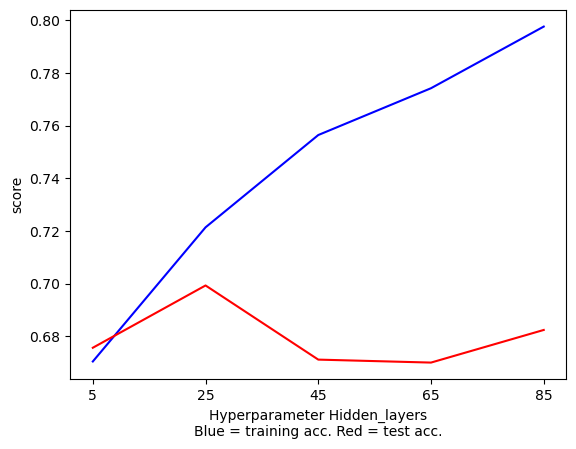

In [9]:
import matplotlib.pyplot as plt
train_result = result_set['split0_train_score']
test_result = result_set['split0_test_score']
print("Total number of models: ", len(test_result))
# plot hidden layers hyperparameter values vs training and test accuracy score
plt.plot(range(0, len(train_result)), train_result, 'b',
range(0,len(test_result)), test_result, 'r')
plt.xlabel('Hyperparameter Hidden_layers\nBlue = training acc. Red = test acc.')
plt.xticks(range(0, len(train_result)),range(5, 86, 20))
plt.ylabel('score')
plt.show()

Total number of models:  5


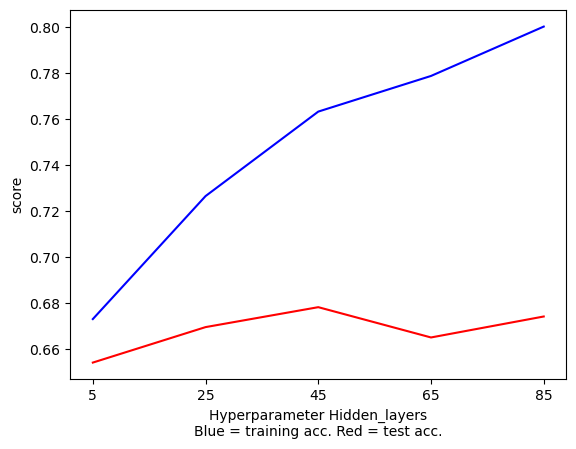

In [10]:
train_result = result_set['mean_train_score']
test_result = result_set['mean_test_score']
print("Total number of models: ", len(test_result))
# plot hidden layers hyperparameter values vs training and test accuracy score
plt.plot(range(0, len(train_result)), train_result, 'b',
range(0,len(test_result)), test_result, 'r')
plt.xlabel('Hyperparameter Hidden_layers\nBlue = training acc. Red = test acc.')
plt.xticks(range(0, len(train_result)),range(5, 86, 20))
plt.ylabel('score')
plt.show()

In [11]:
print("Train accuracy:", cv_1.score(X_train, y_train))
print("Test accuracy:", cv_1.score(X_test, y_test))
y_pred = cv_1.predict(X_test)
print(classification_report(y_test, y_pred))
print(cv_1.best_params_)

Train accuracy: 0.761094841180446
Test accuracy: 0.6962690488702049
              precision    recall  f1-score   support

           0       0.66      0.60      0.63      1643
           1       0.72      0.77      0.74      2163

    accuracy                           0.70      3806
   macro avg       0.69      0.68      0.69      3806
weighted avg       0.69      0.70      0.69      3806

{'hidden_layer_sizes': (45,)}


In [12]:
# new parameters
params = {'hidden_layer_sizes': [(3,), (5,), (7,), (9,)]}
cv_2 = GridSearchCV(param_grid=params,
estimator=MLPClassifier(random_state=random_state), cv=10, n_jobs=-1)

In [13]:
cv_2.fit(X_train, y_train)
print("Train accuracy:", cv_2.score(X_train, y_train))
print("Test accuracy:", cv_2.score(X_test, y_test))
y_pred = cv_2.predict(X_test)
print(classification_report(y_test, y_pred))
print(cv_2.best_params_)

Train accuracy: 0.6887812570398738
Test accuracy: 0.6689437729900157
              precision    recall  f1-score   support

           0       0.64      0.55      0.59      1643
           1       0.69      0.76      0.72      2163

    accuracy                           0.67      3806
   macro avg       0.66      0.65      0.66      3806
weighted avg       0.67      0.67      0.66      3806

{'hidden_layer_sizes': (9,)}


In [14]:
params = {'hidden_layer_sizes': [(3,), (5,), (7,), (9,)], 'alpha': [0.01, 0.001,
0.0001, 0.00001]}
cv_3 = GridSearchCV(param_grid=params,
estimator=MLPClassifier(random_state=random_state), cv=10, n_jobs=-1)
cv_3.fit(X_train, y_train)
print("Train accuracy:", cv_3.score(X_train, y_train))
print("Test accuracy:", cv_3.score(X_test, y_test))
y_pred = cv_3.predict(X_test)
print(classification_report(y_test, y_pred))
print(cv_3.best_params_)

Train accuracy: 0.6888938950214012
Test accuracy: 0.6689437729900157
              precision    recall  f1-score   support

           0       0.64      0.55      0.59      1643
           1       0.69      0.76      0.72      2163

    accuracy                           0.67      3806
   macro avg       0.66      0.65      0.66      3806
weighted avg       0.67      0.67      0.66      3806

{'alpha': 0.01, 'hidden_layer_sizes': (9,)}


In [15]:
# Task 4.3

from sklearn.feature_selection import RFECV


import pickle
from sklearn.feature_selection import SelectFromModel
with open('decision_tree_model.pickle', 'rb') as f:
    dt_best, roc_index_dt_cv, fpr_dt_cv, tpr_dt_cv = pickle.load(f)

    
selectmodel = SelectFromModel(dt_best, prefit=True)
X_train_sel_model = selectmodel.transform(X_train)
X_test_sel_model = selectmodel.transform(X_test)
print(X_train_sel_model.shape)

(8878, 6)


In [16]:
params = {'hidden_layer_sizes': [(3,), (5,), (7,), (9,)], 'alpha': [0.01,0.001,0.0001, 0.00001]}
cv_sel_model = GridSearchCV(param_grid=params,
estimator=MLPClassifier(random_state=random_state), cv=10, n_jobs=-1)
cv_sel_model.fit(X_train_sel_model, y_train)
print("Train accuracy:", cv_sel_model.score(X_train_sel_model, y_train))
print("Test accuracy:", cv_sel_model.score(X_test_sel_model, y_test))
y_pred = cv_sel_model.predict(X_test_sel_model)
print(classification_report(y_test, y_pred))
print(cv_sel_model.best_params_)

Train accuracy: 0.6528497409326425
Test accuracy: 0.6513399894902785
              precision    recall  f1-score   support

           0       0.62      0.51      0.56      1643
           1       0.67      0.76      0.71      2163

    accuracy                           0.65      3806
   macro avg       0.64      0.63      0.64      3806
weighted avg       0.65      0.65      0.65      3806

{'alpha': 1e-05, 'hidden_layer_sizes': (9,)}


Total number of models:  5


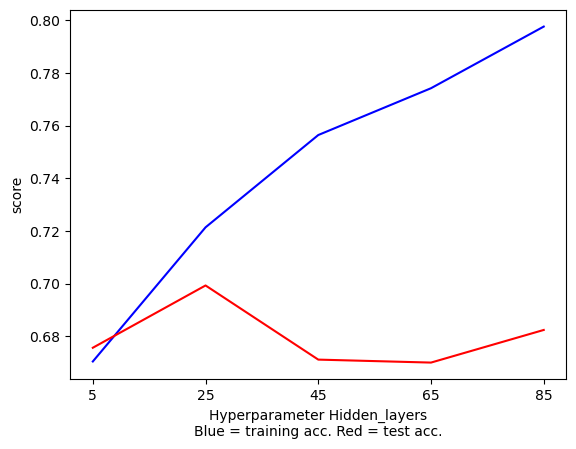

In [17]:
import matplotlib.pyplot as plt
train_result = result_set['split0_train_score']
test_result = result_set['split0_test_score']
print("Total number of models: ", len(test_result))
# plot hidden layers hyperparameter values vs training and test accuracy score
plt.plot(range(0, len(train_result)), train_result, 'b',
range(0,len(test_result)), test_result, 'r')
plt.xlabel('Hyperparameter Hidden_layers\nBlue = training acc. Red = test acc.')
plt.xticks(range(0, len(train_result)),range(5, 86, 20))
plt.ylabel('score')
plt.show()

In [18]:
from sklearn.metrics import roc_auc_score

y_pred_proba_cv_1 = cv_1.predict_proba(X_test)
y_pred_proba_cv_2 = cv_2.predict_proba(X_test)
y_pred_proba_cv_3 = cv_3.predict_proba(X_test)

y_pred_proba_cv_sel_model = cv_sel_model.predict_proba(X_test_sel_model)

In [19]:

roc_index_cv_1 = roc_auc_score(y_test, y_pred_proba_cv_1[:, 1])
roc_index_cv_2 = roc_auc_score(y_test, y_pred_proba_cv_2[:, 1])
roc_index_cv_3 = roc_auc_score(y_test, y_pred_proba_cv_3[:, 1])

roc_index_cv_sel_model = roc_auc_score(y_test, y_pred_proba_cv_sel_model[:, 1])

print("ROC index on test for NN with gridsearch 1:", roc_index_cv_1)
print("ROC index on test for NN with gridsearch 2:", roc_index_cv_2)
print("ROC index on test for NN with gridsearch 3:", roc_index_cv_3)

print("ROC index on test for NN with feature selection (model selection) and gridsearch:", roc_index_cv_sel_model)

ROC index on test for NN with gridsearch 1: 0.7520791072339567
ROC index on test for NN with gridsearch 2: 0.7258378263997868
ROC index on test for NN with gridsearch 3: 0.7288278576592044
ROC index on test for NN with feature selection (model selection) and gridsearch: 0.7080028780387466


In [20]:
from sklearn.metrics import roc_curve

fpr_cv_1, tpr_cv_1, thresholds_cv_1 = roc_curve(y_test, y_pred_proba_cv_1[:,1])
fpr_cv_2, tpr_cv_2, thresholds_cv_2 = roc_curve(y_test, y_pred_proba_cv_2[:,1])
fpr_cv_3, tpr_cv_3, thresholds_cv_3 = roc_curve(y_test, y_pred_proba_cv_3[:,1])

fpr_cv_sel_model, tpr_cv_sel_model, thresholds_cv_sel_model = roc_curve(y_test,y_pred_proba_cv_sel_model[:,1])

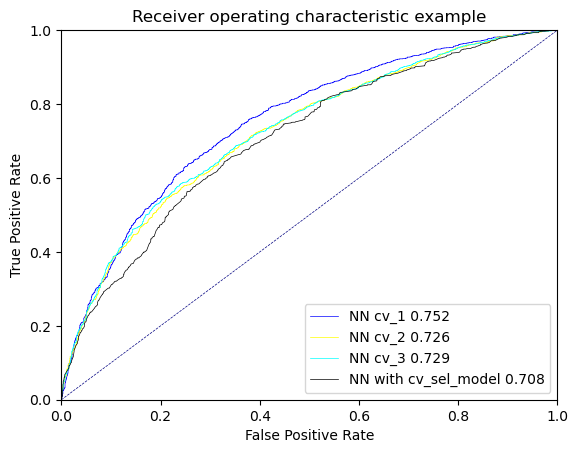

In [21]:
import matplotlib.pyplot as plt

plt.plot(fpr_cv_1, tpr_cv_1, label='NN cv_1 {:.3f}'.format(roc_index_cv_1),
color='blue', lw=0.5)
plt.plot(fpr_cv_2, tpr_cv_2, label='NN cv_2 {:.3f}'.format(roc_index_cv_2),
color='yellow', lw=0.5)
plt.plot(fpr_cv_3, tpr_cv_3, label='NN cv_3 {:.3f}'.format(roc_index_cv_3),
color='cyan', lw=0.5)

plt.plot(fpr_cv_sel_model, tpr_cv_sel_model, label='NN with cv_sel_model {:.3f}'.format(roc_index_cv_sel_model), color='black', lw=0.5)
plt.plot([0, 1], [0, 1], color='navy', lw=0.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [22]:
#Saving Model 
import pickle
with open('neural_network_model.pickle', 'wb') as f:
    pickle.dump([ cv_1,roc_index_cv_1, fpr_cv_1, tpr_cv_1, scaler], f)